In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

Map

In [ ]:
# === 1. Load model and scaling ===
linear_reg = joblib.load("lr_model.pkl")
scaling_df = pd.read_csv("feature_scaling.csv")
scaling_df['feature'] = scaling_df['feature'].replace({
    "dissolved_oxygen": "DO"
})

feature_names = scaling_df['feature'].tolist()
feature_means = scaling_df.set_index('feature')['mean'].to_dict()
feature_stds = scaling_df.set_index('feature')['std'].to_dict()

# === 2. Variable settings ===
depth_levels = [0, 10, 20, 30, 40, 50,60,70, 80, 90, 100, 125, 150,175, 200]
multi_depth_vars = ["salinity", "DO", "Fe", "nitrate", "phosphate", "T"]
single_vars = ["CHL", "MLD", "PAR", "SST"]

target_lat = np.linspace(-89.5, 89.5, 180)
target_lon = np.linspace(-179.5, 179.5, 360)
lon_mesh, lat_mesh = np.meshgrid(target_lon, target_lat)

annual_maps = {}

In [ ]:
# === 3. Loop over depth ===
for depth in depth_levels:
    monthly_maps = []
    for month in range(1, 13):
        feature_data = {}

        # (a) load multi-depth vars
        for var in multi_depth_vars:
            filepath = os.path.join(f"{var}_gridded_{depth}", f"{var}_{month:02d}.npz")
            arr = np.load(filepath)[var]
            feature_data[var] = arr

        # (b) load single-depth vars
        for var in single_vars:
            filepath = os.path.join(f"{var}_gridded", f"{var}_{month:02d}.npz")
            arr = np.load(filepath)[var]
            feature_data[var] = arr

        # (c) log-transform
        epsilon = 1e-6

        def safe_log10(arr):
            arr = np.where(arr > 0, arr, np.nan)  
            return np.log10(arr + epsilon)
        
        feature_data["log_N"]   = safe_log10(feature_data["nitrate"])
        feature_data["log_P"]   = safe_log10(feature_data["phosphate"])
        feature_data["log_Fe"]  = safe_log10(feature_data["Fe"])
        feature_data["log_CHL"] = safe_log10(feature_data["CHL"])
        
        # (d) coord + time
        coord1 = np.sin(np.radians(lat_mesh))
        coord2 = np.sin(np.radians(lon_mesh)) * np.cos(np.radians(lat_mesh))
        coord3 = -np.cos(np.radians(lon_mesh)) * np.cos(np.radians(lat_mesh))
        time_cos = np.cos(2 * np.pi * month / 12) * np.ones_like(coord1)
        time_sin = np.sin(2 * np.pi * month / 12) * np.ones_like(coord1)

        # (e) assemble features
        feature_dict = {
            "MLD": feature_data["MLD"].ravel(),
            "salinity": feature_data["salinity"].ravel(),
            "DO": feature_data["DO"].ravel(),
            "T": feature_data["T"].ravel(),
            "SST(m)": feature_data["SST"].ravel(),
            "log_CHL": feature_data["log_CHL"].ravel(),
            "PAR(m)": feature_data["PAR"].ravel(),
            "log_N": feature_data["log_N"].ravel(),
            "log_P": feature_data["log_P"].ravel(),
            "log_Fe": feature_data["log_Fe"].ravel(),
            "DEPTH (m)": np.full(lon_mesh.shape, depth).ravel(),
            "coord1": coord1.ravel(),
            "coord2": coord2.ravel(),
            "coord3": coord3.ravel(),
            "time_sin": time_sin.ravel(),
            "time_cos": time_cos.ravel()
        }

        # === 4. Flatten grid & feature ===
        nlat, nlon = lon_mesh.shape
        npoints = nlat * nlon
        
        X = [] 
        for fname in feature_names: 
            arr = feature_dict[fname] 
            mean, std = feature_means[fname], feature_stds[fname] 
            X.append((arr - mean) / std)
        X = np.vstack(X).T 

        
        # === 5. valid mask ===
        #lat_mask = (lat_mesh > -50).ravel()
        data_mask = ~np.isnan(X).any(axis=1)
        valid_mask = data_mask #& lat_mask
        
        # pred
        X_valid = X[valid_mask]
        y_pred_log = linear_reg.predict(X_valid)
        y_pred = 10**np.clip(y_pred_log, -3, 3)  
        
        # anomal
        anomaly_mask = y_pred > 100
        print("Anomaly count:", np.sum(anomaly_mask))
        y_pred[anomaly_mask] = np.nan
        
        # === 6. map ===
        pred_map = np.full(npoints, np.nan)
        pred_map[valid_mask] = y_pred
        pred_map = pred_map.reshape(nlat, nlon)

        monthly_maps.append(pred_map)

        out_dir = f"LR"  
        os.makedirs(out_dir, exist_ok=True)
        fpath = f"{out_dir}/month_{month:02d}_depth_{depth}.npy"
        np.save(fpath, pred_map)

    # === 6. Annual mean ===
    annual_map = np.nanmean(monthly_maps, axis=0)
    annual_maps[depth] = annual_map

    # save npz
    # np.savez(f"annual_prediction_depth{depth}.npz",
    #          prediction=annual_map, lon=target_lon, lat=target_lat)

    

In [ ]:
from matplotlib.colors import LogNorm

# === 7. All depths together ===
fig, axes = plt.subplots(5, 3, figsize=(18, 10), constrained_layout=True)

for i, depth in enumerate(depth_levels):
    ax = axes[i//3, i%3]
    data = annual_maps[depth]

    # avoid 0
    positive_vals = data[data > 0]
    if positive_vals.size > 0:
        vmin = np.nanmin(positive_vals)
        vmax = np.nanmax(positive_vals)
    else:
        vmin, vmax = 1e-3, 1  # fallback

    im = ax.imshow(
        data,
        origin="lower",
        cmap="viridis",
        extent=[-180, 180, -90, 90],
        norm=LogNorm(vmin=vmin, vmax=vmax)
    )
    ax.set_title(f"Depth {depth}m")

cbar = fig.colorbar(im, ax=axes, orientation="vertical", shrink=0.8)
cbar.set_label("Annual NF ($\mu$mol N m$^{-3}$ d$^{-1}$)")

plt.suptitle("Annual Predictions at Different Depths (log scale)", fontsize=16)
plt.show()


Calculations

In [2]:
# ==============================
# 1. 基本设置
# ==============================
depth_levels = np.array([0,10,20,30,40,50,60,70,80,90,100,125,150,175,200])


days_in_month = np.array([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])  # 非闰年

# Earth parameter + grid
R = 6371e3
lat = np.linspace(-89.5, 89.5, 180)
lon = np.linspace(-179.5, 179.5, 360)
lat2d, lon2d = np.meshgrid(lat, lon, indexing="ij")
dlat = np.deg2rad(1)
dlon = np.deg2rad(1)
grid_areas = (R**2) * dlon * np.cos(np.deg2rad(lat)) * dlat # (180,)
grid_areas = np.tile(grid_areas[:, np.newaxis], (1, 360)) # (180,360)


In [3]:
# ==============================
# 2. 定义海盆 mask
# ==============================
def basin_mask(lat2d, lon2d, lat_min, lat_max, lon_min, lon_max):
    """矩形mask, 经度可跨180°"""
    if lon_min < lon_max:
        mask = (lat2d >= lat_min) & (lat2d <= lat_max) & (lon2d >= lon_min) & (lon2d <= lon_max)
    else:  # 跨越180°
        mask = (lat2d >= lat_min) & (lat2d <= lat_max) & ((lon2d >= lon_min) | (lon2d <= lon_max))
    return mask

basins = {
    "North Atlantic": basin_mask(lat2d, lon2d, 0, 66, -100, 20),
    "South Atlantic": basin_mask(lat2d, lon2d, -60, 0, -70, 20),
    "North Pacific":  basin_mask(lat2d, lon2d, 0, 66, 120, -100),
    "South Pacific":  basin_mask(lat2d, lon2d, -60, 0, 150, -70),
    "Indian Ocean":   basin_mask(lat2d, lon2d, -40, 30, 20, 150)
}


In [4]:
def process_model_monthly(model_dir, output_dir, model_name, depth_levels):
    """
    使用梯形法则(np.trapezoid)进行深度积分。
    no manually def dz。
    """
    os.makedirs(output_dir, exist_ok=True)

    monthly_predictions = []
    basin_totals = {name: 0 for name in basins}
    global_totals = []

    for month in range(1, 13):
        # === depth levels ===
        month_stack = []
        for d in depth_levels:
            fpath = f"{model_dir}/month_{month:02d}_depth_{d}.npy"
            if not os.path.exists(fpath):
                raise FileNotFoundError(f"Missing file: {fpath}")
            arr = np.load(fpath)
            month_stack.append(arr)
        month_stack = np.array(month_stack)

        # np.trapezoid(y, x, axis)
        # y 是速率值 (month_stack)
        # x 是深度坐标 (depth_levels)
        # 沿深度轴(axis=0)进行积分
        depth_integrated = np.trapezoid(month_stack, depth_levels, axis=0)

        np.save(f"{output_dir}/n2_month_{month:02d}.npy", depth_integrated)
        monthly_predictions.append(depth_integrated)

        # === (global, basin) ===
        monthly_total = depth_integrated * days_in_month[month-1] * grid_areas
        global_totals.append(np.nansum(monthly_total))
        for name, mask in basins.items():
            basin_total = depth_integrated * days_in_month[month-1] * grid_areas * mask
            basin_totals[name] += np.nansum(basin_total)

    # === global annual total ===
    annual_total = np.sum(global_totals)
    annual_Tmol = annual_total * 1e-18
    annual_Tg = annual_Tmol * 28

    print(f"\n=== {model_name} Results (Final Calculation) ===")
    print(f"Global Annual N2 Fixation: {annual_Tg:.2f} Tg N/yr ({annual_Tmol:.2f} Tmol/yr)")
    for name, val in basin_totals.items():
        annual_Tmol = val * 1e-18
        annual_Tg = annual_Tmol * 28
        print(f"{name}: {annual_Tg:.2f} Tg N/yr")

    return monthly_predictions

# --- use ---
# process_model_monthly(
#     model_dir="path/to/your/model/output", 
#     output_dir="path/to/save/integrals", 
#     model_name="LR",
#     depth_levels=depth_levels
# )


In [14]:
# ==============================
# 5. 4 models
# ==============================
# BHLR/month_01_depth_0.npy ... month_12_depth_80.npy
# RF/month_01_depth_0.npy ... 
# LR/month_01_depth_0.npy ...
# ==============================
bhlr_preds = process_model_monthly("BHLR", "out_BHLR", "BHLR", depth_levels)


=== BHLR Results (Final Calculation) ===
Global Annual N2 Fixation: 305.09 Tg N/yr (10.90 Tmol/yr)
North Atlantic: 32.85 Tg N/yr
South Atlantic: 52.29 Tg N/yr
North Pacific: 70.37 Tg N/yr
South Pacific: 92.55 Tg N/yr
Indian Ocean: 50.06 Tg N/yr


In [6]:
rf_preds   = process_model_monthly("RF",   "out_RF",   "RF", depth_levels)


=== RF Results (Final Calculation) ===
Global Annual N2 Fixation: 201.76 Tg N/yr (7.21 Tmol/yr)
North Atlantic: 25.99 Tg N/yr
South Atlantic: 17.66 Tg N/yr
North Pacific: 58.75 Tg N/yr
South Pacific: 57.88 Tg N/yr
Indian Ocean: 36.98 Tg N/yr


In [7]:
lr_preds   = process_model_monthly("LR",   "out_LR",   "LR", depth_levels)


=== LR Results (Final Calculation) ===
Global Annual N2 Fixation: 198.65 Tg N/yr (7.09 Tmol/yr)
North Atlantic: 15.85 Tg N/yr
South Atlantic: 16.73 Tg N/yr
North Pacific: 47.87 Tg N/yr
South Pacific: 61.66 Tg N/yr
Indian Ocean: 49.16 Tg N/yr


In [8]:
tabpfn_preds = process_model_monthly("TabPFN", "out_TabPFN", "TabPFN", depth_levels)


=== TabPFN Results (Final Calculation) ===
Global Annual N2 Fixation: 180.28 Tg N/yr (6.44 Tmol/yr)
North Atlantic: 22.99 Tg N/yr
South Atlantic: 18.20 Tg N/yr
North Pacific: 51.69 Tg N/yr
South Pacific: 45.23 Tg N/yr
Indian Ocean: 40.09 Tg N/yr


Maps

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm
from scipy.ndimage import generic_filter
import seaborn as sns

In [2]:
sns.set(style='white', context='notebook')
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times", "STIX", "DejaVu Serif"],
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13
})

In [3]:


# === 定义 nanmean filter ===
def nanmean_filter(values):
    arr = np.array(values)
    return np.nanmean(arr) if np.any(~np.isnan(arr)) else np.nan

def smooth_fill(arr, iterations=2):
    out = arr.copy()

    for _ in range(iterations):
        nan_mask = np.isnan(out)
        smoothed = generic_filter(
            out, nanmean_filter,
            size=5, mode='constant', cval=np.nan
        )
        out[nan_mask] = smoothed[nan_mask]

    return out




<>:64: SyntaxWarning: invalid escape sequence '\m'
<>:64: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3804763/3020467784.py:64: SyntaxWarning: invalid escape sequence '\m'
  "NF ($\mu$mol N m$^{-3}$ d$^{-1}$)",


Plotting depth: 0 using key: 0
Plotting depth: 10 using key: 10
Plotting depth: 20 using key: 20
Plotting depth: 30 using key: 30
Plotting depth: 40 using key: 40
Plotting depth: 80 using key: 80
Plotting depth: 100 using key: 100
Plotting depth: 150 using key: 150
Plotting depth: 200 using key: 200


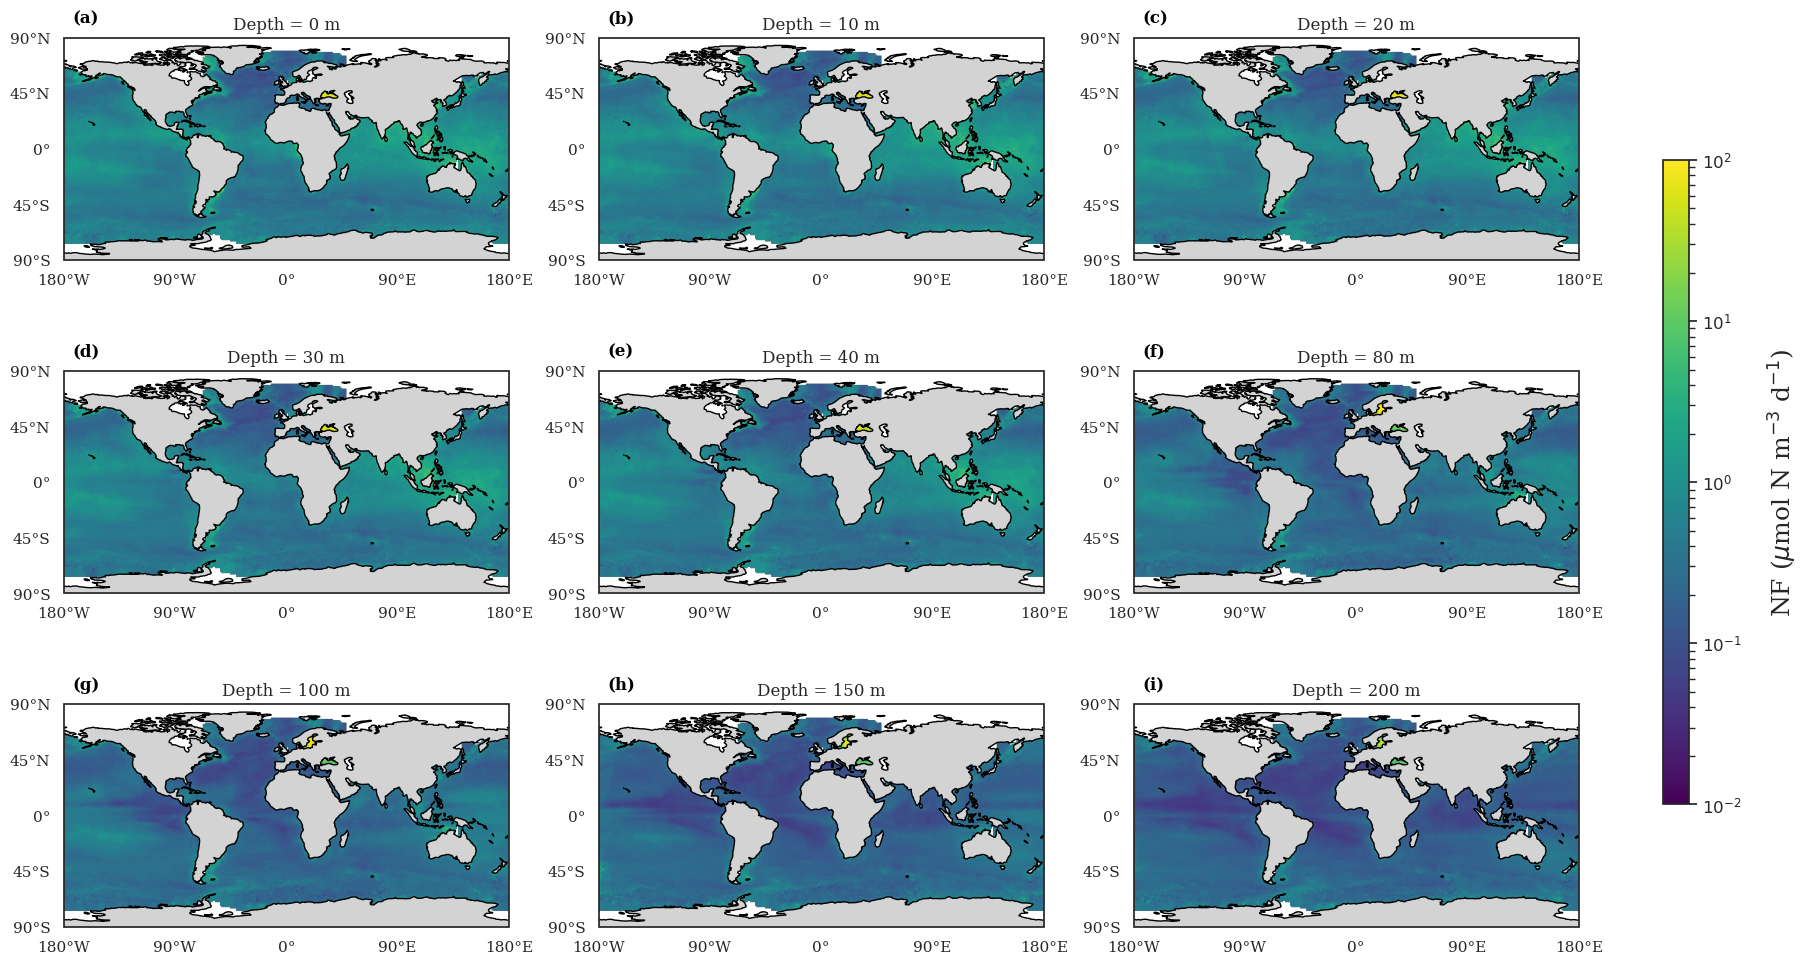

In [4]:
# === 1. Load saved maps ===
data = np.load("LR_annual_depth_maps.npz")
depth_levels = [0, 10, 20, 30, 40, 80, 100, 150, 200]

annual_maps = {int(k): data[k] for k in data.files}

# === 2. Plot with coastlines in 3x3 grid ===
fig, axes = plt.subplots(
    3, 3, figsize=(18, 10),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True
)

vmin, vmax = 1e-2, 1e2
cbar_ticks = [1e-2, 1e-1, 1, 10, 100]
panel_labels = [f"({chr(97+i)})" for i in range(9)]

# === 绘图循环 ===
for i, depth in enumerate(depth_levels):
    ax = axes[i//3, i%3]
    
    # 对当前层数据进行 smooth fill
    smoothed_map = smooth_fill(annual_maps[depth])
    
    im = ax.imshow(
        smoothed_map,
        origin="lower",
        cmap="viridis",
        extent=[-180, 180, -90, 90],
        transform=ccrs.PlateCarree(),
        norm=LogNorm(vmin=vmin, vmax=vmax)
    )
    
    # 海陆特征
    ax.coastlines(resolution="110m", linewidth=1)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    
    # 经纬度刻度
    ax.set_xticks([-180, -90, 0, 90, 180], crs=ccrs.PlateCarree())
    ax.set_yticks([-90, -45, 0, 45, 90], crs=ccrs.PlateCarree())
    ax.set_xticklabels(['180°W','90°W','0°','90°E','180°E'])
    ax.set_yticklabels(['90°S','45°S','0°','45°N','90°N'])
    
    # 标注 (a)-(i) 放上方黑色
    ax.text(
        0.02, 1.05,
        panel_labels[i],
        fontsize=12, fontweight="bold", color="black",
        ha="left", va="bottom",
        transform=ax.transAxes
    )
    
    ax.set_title(f"Depth = {depth} m", fontsize=12)
    print("Plotting depth:", depth, "using key:", depth)


# === Colorbar 优化 ===
cbar = fig.colorbar(
    im, ax=axes.ravel().tolist(),
    orientation="vertical", shrink=0.65, pad=0.04,
    aspect=25, ticks=cbar_ticks
)
cbar.set_label(
    "NF ($\mu$mol N m$^{-3}$ d$^{-1}$)",
    labelpad=18, fontsize=18
)
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_yticklabels([f"$10^{{{int(np.log10(t))}}}$" for t in cbar_ticks])

plt.savefig("LR_depth_maps.png", dpi=300)
plt.show()


<>:64: SyntaxWarning: invalid escape sequence '\m'
<>:64: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2996178/2838003568.py:64: SyntaxWarning: invalid escape sequence '\m'
  "NF ($\mu$mol N m$^{-3}$ d$^{-1}$)",


Plotting depth: 0 using key: 0
Plotting depth: 10 using key: 10
Plotting depth: 20 using key: 20
Plotting depth: 30 using key: 30
Plotting depth: 40 using key: 40
Plotting depth: 80 using key: 80


Plotting depth: 100 using key: 100
Plotting depth: 150 using key: 150
Plotting depth: 200 using key: 200


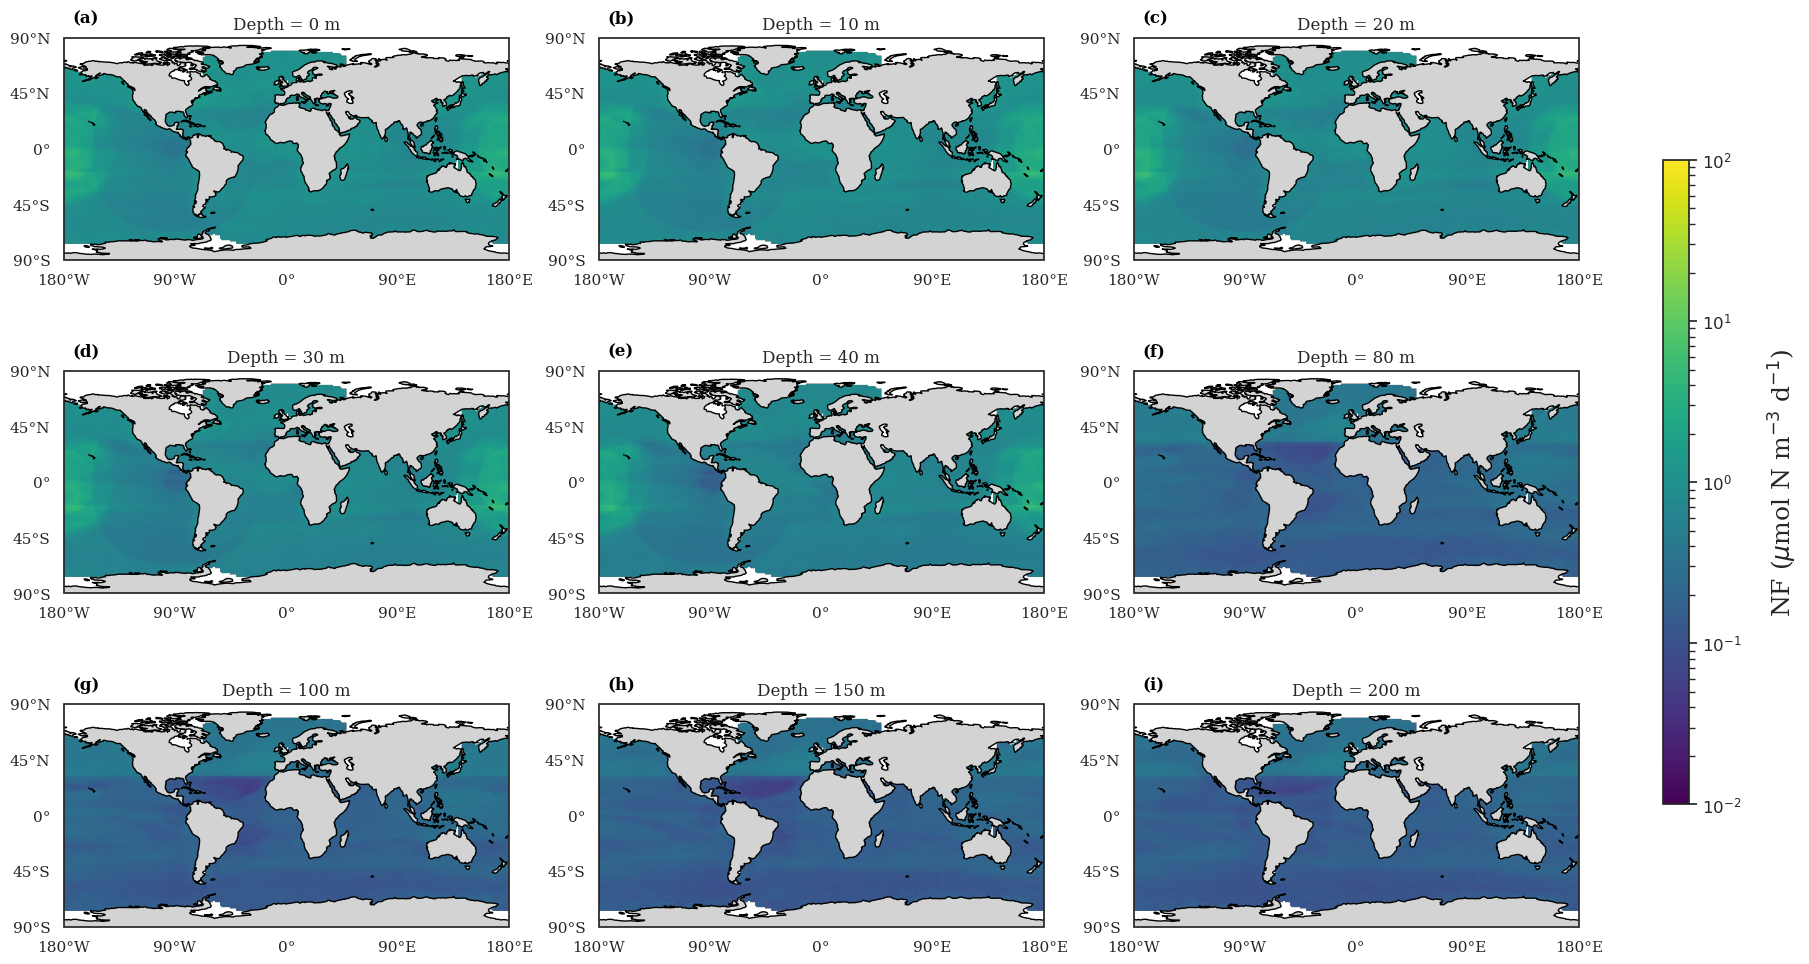

In [36]:
# === 1. Load saved maps ===
data = np.load("RF_annual_depth_maps.npz")
depth_levels = [0, 10, 20, 30, 40, 80, 100, 150, 200]

annual_maps = {int(k): data[k] for k in data.files}

# === 2. Plot with coastlines in 3x3 grid ===
fig, axes = plt.subplots(
    3, 3, figsize=(18, 10),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True
)

vmin, vmax = 1e-2, 1e2
cbar_ticks = [1e-2, 1e-1, 1, 10, 100]
panel_labels = [f"({chr(97+i)})" for i in range(9)]

# === 绘图循环 ===
for i, depth in enumerate(depth_levels):
    ax = axes[i//3, i%3]
    
    # 对当前层数据进行 smooth fill
    smoothed_map = smooth_fill(annual_maps[depth])
    
    im = ax.imshow(
        smoothed_map,
        origin="lower",
        cmap="viridis",
        extent=[-180, 180, -90, 90],
        transform=ccrs.PlateCarree(),
        norm=LogNorm(vmin=vmin, vmax=vmax)
    )
    
    # 海陆特征
    ax.coastlines(resolution="110m", linewidth=1)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    
    # 经纬度刻度
    ax.set_xticks([-180, -90, 0, 90, 180], crs=ccrs.PlateCarree())
    ax.set_yticks([-90, -45, 0, 45, 90], crs=ccrs.PlateCarree())
    ax.set_xticklabels(['180°W','90°W','0°','90°E','180°E'])
    ax.set_yticklabels(['90°S','45°S','0°','45°N','90°N'])
    
    # 标注 (a)-(i) 放上方黑色
    ax.text(
        0.02, 1.05,
        panel_labels[i],
        fontsize=12, fontweight="bold", color="black",
        ha="left", va="bottom",
        transform=ax.transAxes
    )
    
    ax.set_title(f"Depth = {depth} m", fontsize=12)
    print("Plotting depth:", depth, "using key:", depth)


# === Colorbar 优化 ===
cbar = fig.colorbar(
    im, ax=axes.ravel().tolist(),
    orientation="vertical", shrink=0.65, pad=0.04,
    aspect=25, ticks=cbar_ticks
)
cbar.set_label(
    "NF ($\mu$mol N m$^{-3}$ d$^{-1}$)",
    labelpad=18, fontsize=18
)
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_yticklabels([f"$10^{{{int(np.log10(t))}}}$" for t in cbar_ticks])

plt.savefig("RF_depth_maps.png", dpi=300)
plt.show()


<>:63: SyntaxWarning: invalid escape sequence '\m'
<>:63: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3221481/3422968510.py:63: SyntaxWarning: invalid escape sequence '\m'
  "NF ($\mu$mol N m$^{-3}$ d$^{-1}$)",


Plotting depth: 0 using key: 0
Plotting depth: 10 using key: 10
Plotting depth: 20 using key: 20
Plotting depth: 30 using key: 30
Plotting depth: 40 using key: 40
Plotting depth: 80 using key: 80
Plotting depth: 100 using key: 100
Plotting depth: 150 using key: 150
Plotting depth: 200 using key: 200


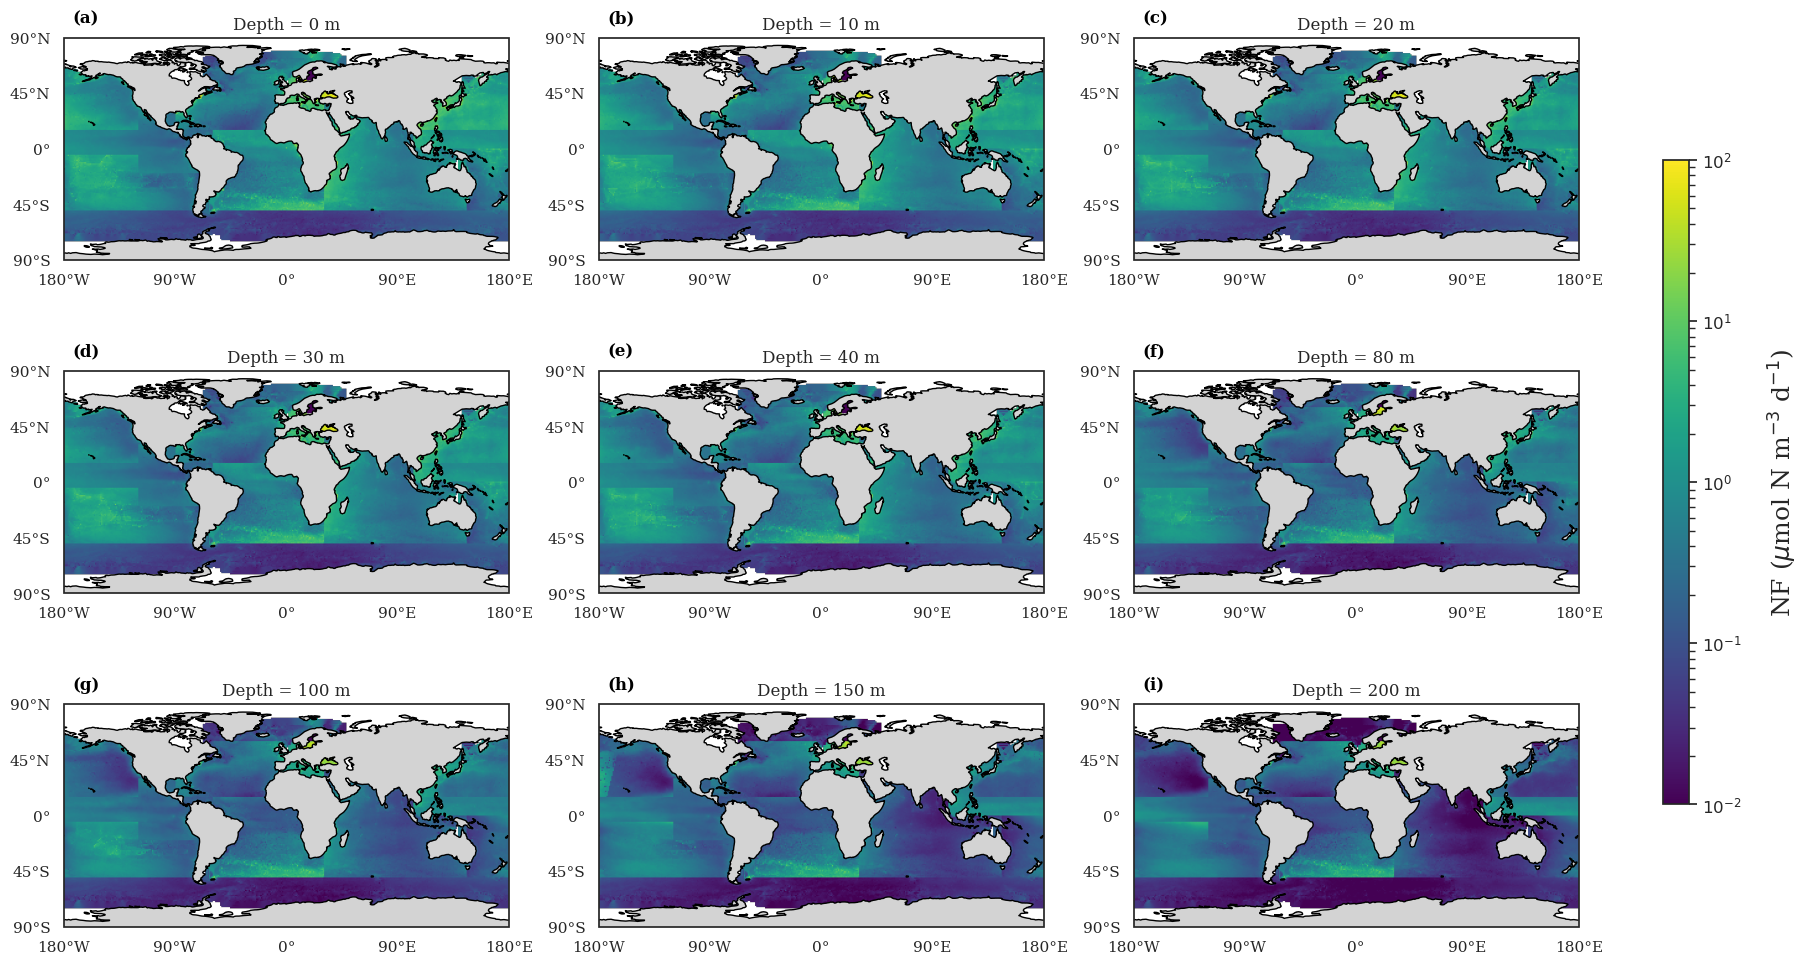

In [18]:
# === 1. Load saved maps ===
data = np.load("BHLR_annual_depth_maps.npz")
depth_levels = [0, 10, 20, 30, 40, 80, 100, 150, 200]
annual_maps = {int(k): data[k] for k in data.files}

# === 2. Plot with coastlines in 3x3 grid ===
fig, axes = plt.subplots(
    3, 3, figsize=(18, 10),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True
)

vmin, vmax = 1e-2, 1e2
cbar_ticks = [1e-2, 1e-1, 1, 10, 100]
panel_labels = [f"({chr(97+i)})" for i in range(9)]

# === 绘图循环 ===
for i, depth in enumerate(depth_levels):
    ax = axes[i//3, i%3]
    
    # 对当前层数据进行 smooth fill
    smoothed_map = smooth_fill(annual_maps[depth])
    
    im = ax.imshow(
        smoothed_map,
        origin="lower",
        cmap="viridis",
        extent=[-180, 180, -90, 90],
        transform=ccrs.PlateCarree(),
        norm=LogNorm(vmin=vmin, vmax=vmax)
    )
    
    # 海陆特征
    ax.coastlines(resolution="110m", linewidth=1)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    
    # 经纬度刻度
    ax.set_xticks([-180, -90, 0, 90, 180], crs=ccrs.PlateCarree())
    ax.set_yticks([-90, -45, 0, 45, 90], crs=ccrs.PlateCarree())
    ax.set_xticklabels(['180°W','90°W','0°','90°E','180°E'])
    ax.set_yticklabels(['90°S','45°S','0°','45°N','90°N'])
    
    # 标注 (a)-(i) 放上方黑色
    ax.text(
        0.02, 1.05,
        panel_labels[i],
        fontsize=12, fontweight="bold", color="black",
        ha="left", va="bottom",
        transform=ax.transAxes
    )
    
    ax.set_title(f"Depth = {depth} m", fontsize=12)
    print("Plotting depth:", depth, "using key:", depth)


# === Colorbar ===
cbar = fig.colorbar(
    im, ax=axes.ravel().tolist(),
    orientation="vertical", shrink=0.65, pad=0.04,
    aspect=25, ticks=cbar_ticks
)
cbar.set_label(
    "NF ($\mu$mol N m$^{-3}$ d$^{-1}$)",
    labelpad=18, fontsize=18
)
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_yticklabels([f"$10^{{{int(np.log10(t))}}}$" for t in cbar_ticks])

plt.savefig("BHLR_depth_maps.png", dpi=300)
plt.show()


<>:63: SyntaxWarning: invalid escape sequence '\m'
<>:63: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2996178/2050027500.py:63: SyntaxWarning: invalid escape sequence '\m'
  "NF ($\mu$mol N m$^{-3}$ d$^{-1}$)",


Plotting depth: 0 using key: 0
Plotting depth: 10 using key: 10
Plotting depth: 20 using key: 20
Plotting depth: 30 using key: 30
Plotting depth: 40 using key: 40
Plotting depth: 80 using key: 80
Plotting depth: 100 using key: 100
Plotting depth: 150 using key: 150
Plotting depth: 200 using key: 200


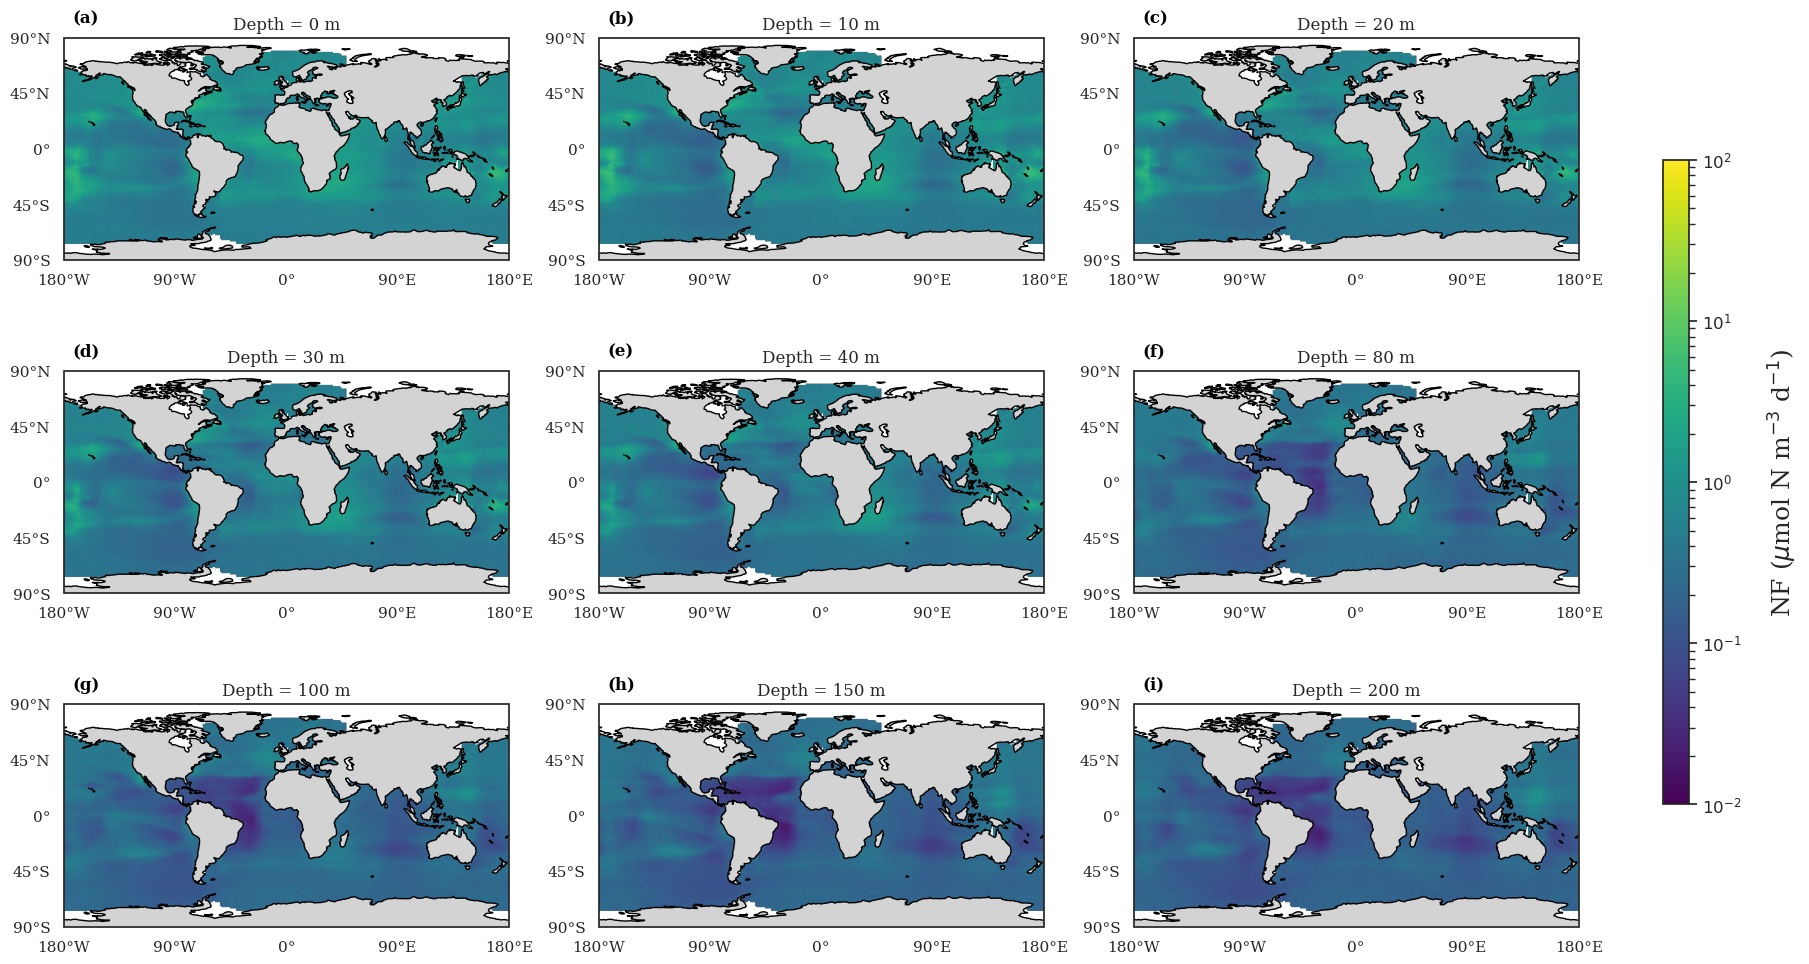

In [38]:
# === 1. Load saved maps ===
data = np.load("TabPFN_annual_depth_maps.npz")
depth_levels = [0, 10, 20, 30, 40, 80, 100, 150, 200]
annual_maps = {int(k): data[k] for k in data.files}

# === 2. Plot with coastlines in 3x3 grid ===
fig, axes = plt.subplots(
    3, 3, figsize=(18, 10),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True
)

vmin, vmax = 1e-2, 1e2
cbar_ticks = [1e-2, 1e-1, 1, 10, 100]
panel_labels = [f"({chr(97+i)})" for i in range(9)]

# === 绘图循环 ===
for i, depth in enumerate(depth_levels):
    ax = axes[i//3, i%3]
    
    # 对当前层数据进行 smooth fill
    smoothed_map = smooth_fill(annual_maps[depth])
    
    im = ax.imshow(
        smoothed_map,
        origin="lower",
        cmap="viridis",
        extent=[-180, 180, -90, 90],
        transform=ccrs.PlateCarree(),
        norm=LogNorm(vmin=vmin, vmax=vmax)
    )
    
    # 海陆特征
    ax.coastlines(resolution="110m", linewidth=1)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    
    # 经纬度刻度
    ax.set_xticks([-180, -90, 0, 90, 180], crs=ccrs.PlateCarree())
    ax.set_yticks([-90, -45, 0, 45, 90], crs=ccrs.PlateCarree())
    ax.set_xticklabels(['180°W','90°W','0°','90°E','180°E'])
    ax.set_yticklabels(['90°S','45°S','0°','45°N','90°N'])
    
    # 标注 (a)-(i) 放上方黑色
    ax.text(
        0.02, 1.05,
        panel_labels[i],
        fontsize=12, fontweight="bold", color="black",
        ha="left", va="bottom",
        transform=ax.transAxes
    )
    
    ax.set_title(f"Depth = {depth} m", fontsize=12)
    print("Plotting depth:", depth, "using key:", depth)


# === Colorbar 优化 ===
cbar = fig.colorbar(
    im, ax=axes.ravel().tolist(),
    orientation="vertical", shrink=0.65, pad=0.04,
    aspect=25, ticks=cbar_ticks
)
cbar.set_label(
    "NF ($\mu$mol N m$^{-3}$ d$^{-1}$)",
    labelpad=18, fontsize=18
)
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_yticklabels([f"$10^{{{int(np.log10(t))}}}$" for t in cbar_ticks])

plt.savefig("TabPFN_depth_maps.png", dpi=300)
plt.show()


Surface

In [5]:
import numpy as np

# ==============================
# depth
# ==============================
depth_levels = np.array([0,10,20,30,40,50,60,70,80,90,100,125,150,175,200])

def compute_surface_integrated(npz_path, out_path):
    """
    annual depth maps (μmol m⁻³ d⁻¹)
    0-200 m surface-integrated flux (μmol m⁻² d⁻¹)
    trapezoidal integration
    """

    data = np.load(npz_path)

    # (depth, lat, lon)
    stacks = []
    for d in depth_levels:
        stacks.append(data[str(d)])

    stacks = np.array(stacks)  # shape = (15,180,360)

    # trapezoidal integration
    surface_flux = np.trapz(stacks, depth_levels, axis=0)

    np.save(out_path, surface_flux)

    print(f"Saved: {out_path}")
    print(f"Min/Max: {np.nanmin(surface_flux):.3e}, {np.nanmax(surface_flux):.3e}")


# ==============================
# 4 models
# ==============================
models = {
    "TabPFN": "TabPFN_annual_depth_maps.npz",
    "BHLR":   "BHLR_annual_depth_maps.npz",
    "LR":     "LR_annual_depth_maps.npz",
    "RF":     "RF_annual_depth_maps.npz",
}

for name, f in models.items():
    
    compute_surface_integrated(
        f,
        f"{name}_surface_integrated.npy"
    )

/tmp/ipykernel_3804763/3597900972.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  surface_flux = np.trapz(stacks, depth_levels, axis=0)


Saved: TabPFN_surface_integrated.npy
Min/Max: 1.047e+01, 3.594e+02
Saved: BHLR_surface_integrated.npy
Min/Max: 9.366e-02, 1.279e+04
Saved: LR_surface_integrated.npy
Min/Max: 5.805e+00, 6.139e+03
Saved: RF_surface_integrated.npy
Min/Max: 2.909e+01, 2.780e+02


In [6]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm


<>:69: SyntaxWarning: invalid escape sequence '\m'
<>:69: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3804763/502402677.py:69: SyntaxWarning: invalid escape sequence '\m'
  "Surface-integrated NF ($\mu$mol N m$^{-2}$ d$^{-1}$)",


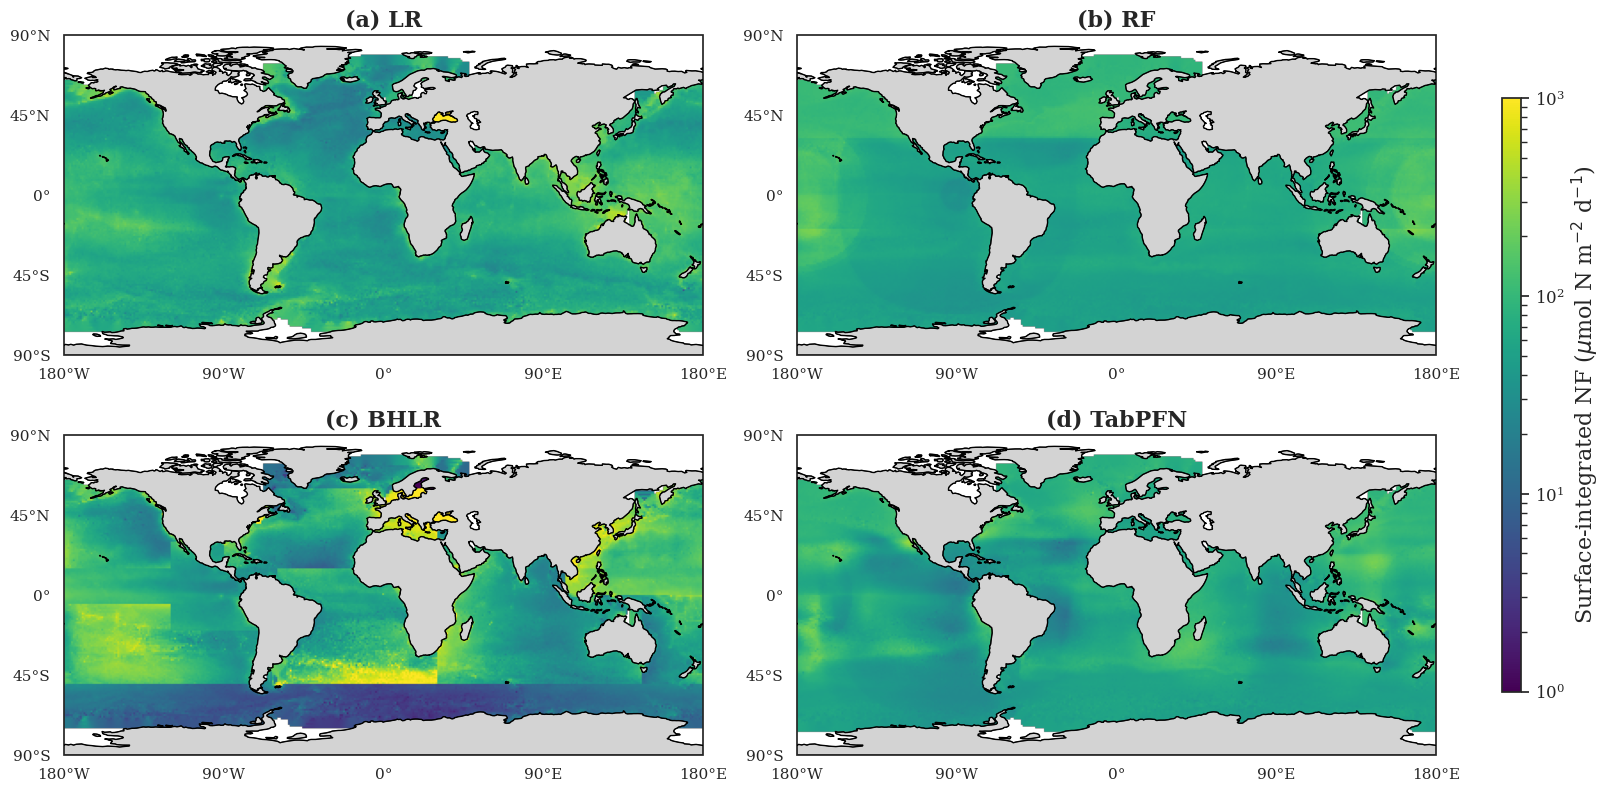

In [7]:

# ==============================
#  surface maps
# ==============================
surface_maps = {
    "LR":     np.load("LR_surface_integrated.npy"),
    "RF":     np.load("RF_surface_integrated.npy"),
    "BHLR":   np.load("BHLR_surface_integrated.npy"),
    "TabPFN": np.load("TabPFN_surface_integrated.npy")
}

# ==============================
# plot
# ==============================
fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 8),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

vmin, vmax = 1, 1000
cbar_ticks = [1, 10, 100, 1000]
panel_labels = ["(a)", "(b)", "(c)", "(d)"]

for ax, ((name, data), label) in zip(axes.ravel(), zip(surface_maps.items(), panel_labels)):
    data = smooth_fill(data)

    im = ax.imshow(
        data,
        origin="lower",
        extent=[-180, 180, -90, 90],
        transform=ccrs.PlateCarree(),
        cmap="viridis",
        norm=LogNorm(vmin=vmin, vmax=vmax),
        zorder=1
    )

    # land & coastlines ON TOP
    ax.add_feature(
        cfeature.LAND,
        facecolor="lightgray",
        edgecolor="black",
        linewidth=0.5,
        zorder=2
    )
    ax.coastlines(resolution="110m", linewidth=1, zorder=3)
    
    # 经纬度刻度
    ax.set_xticks([-180, -90, 0, 90, 180], crs=ccrs.PlateCarree())
    ax.set_yticks([-90, -45, 0, 45, 90], crs=ccrs.PlateCarree())
    ax.set_xticklabels(['180°W','90°W','0°','90°E','180°E'])
    ax.set_yticklabels(['90°S','45°S','0°','45°N','90°N'])

    # title with panel label
    ax.set_title(f"{label} {name}", fontsize=16, fontweight="bold")


# colorbar
cbar = fig.colorbar(
    im,
    ax=axes.ravel().tolist(),
    orientation="vertical",
    shrink=0.75,
    pad=0.03,
    aspect=30,
    ticks=cbar_ticks
)
cbar.set_label(
    "Surface-integrated NF ($\mu$mol N m$^{-2}$ d$^{-1}$)",
    fontsize=16
)
cbar.ax.tick_params(labelsize=12)

plt.savefig("Surface_N2_fixation_4models.png", dpi=300)
plt.show()


<>:81: SyntaxWarning: invalid escape sequence '\m'
<>:81: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3804763/396743906.py:81: SyntaxWarning: invalid escape sequence '\m'
  "Surface-integrated NF ($\mu$mol N m$^{-2}$ d$^{-1}$)",


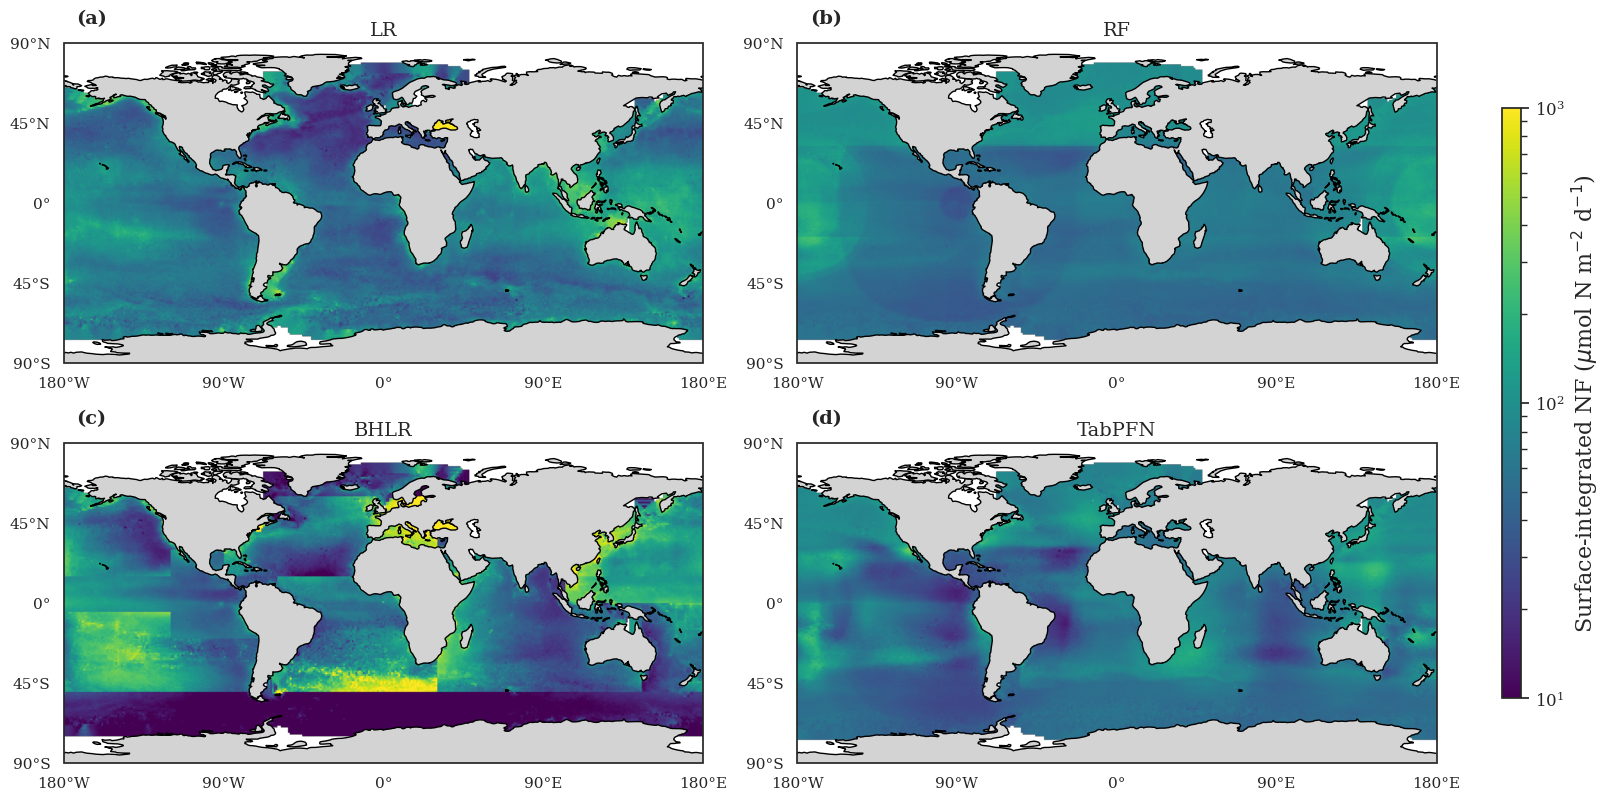

In [8]:
# ==============================
#  Load surface maps
# ==============================
surface_maps = {
    "LR":     np.load("LR_surface_integrated.npy"),
    "RF":     np.load("RF_surface_integrated.npy"),
    "BHLR":   np.load("BHLR_surface_integrated.npy"),
    "TabPFN": np.load("TabPFN_surface_integrated.npy")
}

model_names = list(surface_maps.keys())

# ==============================
#  Plot: 2x2 with coastlines
# ==============================
fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 8),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True
)

vmin, vmax = 10, 1000
cbar_ticks = [10, 100, 1000]
panel_labels = ["(a)", "(b)", "(c)", "(d)"]

# ==============================
#  Plot loop
# ==============================
for i, (name, data) in enumerate(surface_maps.items()):
    ax = axes[i // 2, i % 2]

    # smooth fill（与 depth 图一致）
    data_filled = smooth_fill(data)

    im = ax.imshow(
        data_filled,
        origin="lower",
        extent=[-180, 180, -90, 90],
        transform=ccrs.PlateCarree(),
        cmap="viridis",
        norm=LogNorm(vmin=vmin, vmax=vmax)
    )

    # 海陆
    ax.coastlines(resolution="110m", linewidth=1)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)

    # 经纬度刻度（与 depth 图完全一致）
    ax.set_xticks([-180, -90, 0, 90, 180], crs=ccrs.PlateCarree())
    ax.set_yticks([-90, -45, 0, 45, 90], crs=ccrs.PlateCarree())
    ax.set_xticklabels(['180°W','90°W','0°','90°E','180°E'])
    ax.set_yticklabels(['90°S','45°S','0°','45°N','90°N'])

    # panel label (a)(b)(c)(d) —— 和 3×3 depth 图一致
    ax.text(
        0.02, 1.05,
        panel_labels[i],
        fontsize=14, fontweight="bold",
        ha="left", va="bottom",
        transform=ax.transAxes
    )

    # model name 单独作为 title（不带 label）
    ax.set_title(name, fontsize=14)

# ==============================
#  Colorbar
# ==============================
cbar = fig.colorbar(
    im,
    ax=axes.ravel().tolist(),
    orientation="vertical",
    shrink=0.75,
    pad=0.03,
    aspect=30,
    ticks=cbar_ticks
)

cbar.set_label(
    "Surface-integrated NF ($\mu$mol N m$^{-2}$ d$^{-1}$)",
    fontsize=16
)
cbar.ax.tick_params(labelsize=12)

plt.savefig("Surface_N2_fixation_4models.png", dpi=300)
plt.show()
